In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
import sklearn
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from nltk.corpus import stopwords
import nltk
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
import umap.umap_ as umap
import string
import math
import spacy
from spacy.lang.en.stop_words import STOP_WORDS as en_stop
from spacy.lang.es.stop_words import STOP_WORDS as es_stop

In [2]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lucfaessler/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Set paths

Data path

In [3]:
path_dataset = "2025 EXIST/EXIST 2025 Tweets Dataset/training/EXIST2025_training.json"

Evaluation paths for task 1.1

In [4]:
path_hard_eval1_1 = "2025 EXIST/evaluation/golds/EXIST2025_training_task1_1_gold_hard.json"
path_soft_eval1_1 = "2025 EXIST/evaluation/golds/EXIST2025_training_task1_1_gold_soft.json"

Evaluation paths for task 1.2

In [5]:
path_hard_eval1_2 = "2025 EXIST/evaluation/golds/EXIST2025_training_task1_2_gold_hard.json"
path_soft_eval1_2 = "2025 EXIST/evaluation/golds/EXIST2025_training_task1_2_gold_soft.json"

Evaluation paths for task 1.3

In [6]:
path_hard_eval1_3 = "2025 EXIST/evaluation/golds/EXIST2025_training_task1_3_gold_hard.json"
path_soft_eval1_3 = "2025 EXIST/evaluation/golds/EXIST2025_training_task1_3_gold_soft.json"

In [7]:
def load_data(path):
    with open(path, "r", encoding="utf-8") as f:
        raw_data = json.load(f)
        
    df_raw = pd.DataFrame.from_dict(raw_data, orient="index").reset_index()
    df_raw = df_raw.rename(columns={"index": "id"})
    return df_raw

In [8]:
def load_eval(path):
    with open(path, 'r', encoding='utf-8') as f:
        data_from_file = json.load(f)

    df = pd.DataFrame(data_from_file)
    return df

## Load data

In [9]:
# loading the dataset
data = load_data(path_dataset)

In [10]:
# first entries of the raw dataset
data[:5]

,id,id_EXIST,lang,tweet,number_annotators,annotators,gender_annotators,age_annotators,ethnicities_annotators,study_levels_annotators,countries_annotators,labels_task1_1,labels_task1_2,labels_task1_3,split
0,100001,100001,es,"@TheChiflis Ignora al otro, es un capullo.El p...",6,"[Annotator_1, Annotator_2, Annotator_3, Annota...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 23-45, 18-22]","[White or Caucasian, Hispano or Latino, White ...","[Bachelor’s degree, Bachelor’s degree, High sc...","[Italy, Mexico, United States, Spain, Spain, C...","[YES, YES, NO, YES, YES, YES]","[REPORTED, JUDGEMENTAL, -, REPORTED, JUDGEMENT...","[[OBJECTIFICATION], [OBJECTIFICATION, SEXUAL-V...",TRAIN_ES
1,100002,100002,es,@ultimonomada_ Si comicsgate se parece en algo...,6,"[Annotator_7, Annotator_8, Annotator_9, Annota...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 23-45, 18-22]","[Black or African American, Hispano or Latino,...","[High school degree or equivalent, Bachelor’s ...","[United Kingdom, Mexico, United States, Portug...","[NO, NO, NO, NO, YES, NO]","[-, -, -, -, DIRECT, -]","[[-], [-], [-], [-], [OBJECTIFICATION], [-]]",TRAIN_ES
2,100003,100003,es,"@Steven2897 Lee sobre Gamergate, y como eso ha...",6,"[Annotator_7, Annotator_8, Annotator_9, Annota...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 23-45, 18-22]","[Black or African American, Hispano or Latino,...","[High school degree or equivalent, Bachelor’s ...","[United Kingdom, Mexico, United States, Portug...","[NO, NO, NO, NO, NO, NO]","[-, -, -, -, -, -]","[[-], [-], [-], [-], [-], [-]]",TRAIN_ES
3,100004,100004,es,@Lunariita7 Un retraso social bastante lamenta...,6,"[Annotator_13, Annotator_14, Annotator_15, Ann...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 23-45, 18-22]","[Hispano or Latino, Hispano or Latino, White o...","[High school degree or equivalent, Bachelor’s ...","[Mexico, Chile, Spain, Spain, Portugal, Spain]","[NO, NO, YES, NO, YES, YES]","[-, -, DIRECT, -, REPORTED, REPORTED]","[[-], [-], [IDEOLOGICAL-INEQUALITY], [-], [IDE...",TRAIN_ES
4,100005,100005,es,@novadragon21 @icep4ck @TvDannyZ Entonces como...,6,"[Annotator_19, Annotator_20, Annotator_21, Ann...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 23-45, 18-22]","[Hispano or Latino, Hispano or Latino, White o...","[Bachelor’s degree, Bachelor’s degree, Master’...","[Mexico, Afghanistan, United States, Italy, Po...","[YES, NO, YES, NO, YES, YES]","[REPORTED, -, JUDGEMENTAL, -, JUDGEMENTAL, DIR...","[[STEREOTYPING-DOMINANCE, OBJECTIFICATION], [-...",TRAIN_ES


## Load evaluations and append to dataset

In [11]:
# Excluded 'NO' category for task 1.2 and 1.3 to avoid duplication
classes_task1_1 = ['YES', 'NO']
classes_task1_2 = ['NO','DIRECT','REPORTED','JUDGEMENTAL']
classes_task1_3 = ['NO','IDEOLOGICAL-INEQUALITY', 'MISOGYNY-NON-SEXUAL-VIOLENCE',
                   'STEREOTYPING-DOMINANCE', 'OBJECTIFICATION','SEXUAL-VIOLENCE']

In [12]:
# Load soft and hard evaluations from disk
hard_eval1_1 = load_eval(path_hard_eval1_1)
soft_eval1_1 = load_eval(path_soft_eval1_1)

# Rename target columns
hard_eval1_1 = hard_eval1_1.rename(columns={'value': 'hard_eval1_1'})
soft_eval1_1 = soft_eval1_1.rename(columns={'value': 'soft_eval1_1'})

# One-hot encode based on the string values in the column
hard_eval1_1_one_hot_df = pd.get_dummies(hard_eval1_1['hard_eval1_1']).reindex(columns=classes_task1_1, fill_value=0)
hard_eval1_1 = pd.concat([hard_eval1_1, hard_eval1_1_one_hot_df], axis=1)

# Split soft evaluation targets
dict1_1_df = pd.DataFrame(soft_eval1_1['soft_eval1_1'].apply(
    lambda d: {k: d.get(k, 0) for k in classes_task1_1} if isinstance(d, dict) else {k: 0 for k in classes_task1_1}
    ).tolist())
dict1_1_df.columns = [f'{col}_freq' for col in dict1_1_df.columns]
soft_eval1_1 = pd.concat([soft_eval1_1,dict1_1_df], axis=1)

# Append encoded evaluations to dataset
data = pd.merge(data, hard_eval1_1[['id','YES', 'NO']], on='id', how='left')
data = pd.merge(data, soft_eval1_1[['id','YES_freq','NO_freq']], on='id', how='left')

In [13]:
#print(soft_eval1_1[:5])
print(len(hard_eval1_1))
print(len(data))

6064
6920


In [14]:
# Load soft and hard evaluations from disk
hard_eval1_2 = load_eval(path_hard_eval1_2)
soft_eval1_2 = load_eval(path_soft_eval1_2)

# Rename target columns
hard_eval1_2 = hard_eval1_2.rename(columns={'value': 'hard_eval1_2'})
soft_eval1_2 = soft_eval1_2.rename(columns={'value': 'soft_eval1_2'})

# One hot encode hard evaluation targets
hard_eval1_2_one_hot_df = pd.get_dummies(hard_eval1_2['hard_eval1_2']).reindex(columns=classes_task1_2, fill_value=0)
hard_eval1_2 = pd.concat([hard_eval1_2, hard_eval1_2_one_hot_df], axis=1)
hard_eval1_2 = hard_eval1_2.rename(columns={'NO': 'NO_2'})

# Split soft evaluation targets
dict1_2_df = pd.DataFrame(soft_eval1_2['soft_eval1_2'].apply(
    lambda d: {k: d.get(k, 0) for k in classes_task1_2} if isinstance(d, dict) else {k: 0 for k in classes_task1_2}
    ).tolist())
dict1_2_df.columns = [f'{col}_freq' for col in dict1_2_df.columns]
soft_eval1_2 = pd.concat([soft_eval1_2,dict1_2_df], axis=1)

# Append to dataset
data = pd.merge(data, hard_eval1_2[['id','NO_2','DIRECT','REPORTED','JUDGEMENTAL']], on='id', how='left')
data = pd.merge(data, soft_eval1_2[['id','DIRECT_freq','REPORTED_freq','JUDGEMENTAL_freq']], on='id', how='left')

In [15]:
# Load soft and hard evaluations from disk
hard_eval1_3 = load_eval(path_hard_eval1_3)
soft_eval1_3 = load_eval(path_soft_eval1_3)

# Rename target columns
hard_eval1_3 = hard_eval1_3.rename(columns={'value': 'hard_eval1_3'})
soft_eval1_3 = soft_eval1_3.rename(columns={'value': 'soft_eval1_3'})

# One hot encode hard evaluation targets
list1_3_df = pd.DataFrame(hard_eval1_3['hard_eval1_3'].apply(
    lambda lst: {k: k in lst for k in classes_task1_3} if isinstance(lst, list) else {k: False for k in classes_task1_3}
    ).tolist())
hard_eval1_3 = pd.concat([hard_eval1_3,list1_3_df], axis=1)
hard_eval1_3 = hard_eval1_3.rename(columns={'NO': 'NO_3'})

# Split soft evaluation targets
dict1_3_df = pd.DataFrame(soft_eval1_3['soft_eval1_3'].apply(
    lambda d: {k: d.get(k, 0) for k in classes_task1_3} if isinstance(d, dict) else {k: 0 for k in classes_task1_3}
    ).tolist())
dict1_3_df.columns = [f'{col}_freq' for col in dict1_3_df.columns]
soft_eval1_3 = pd.concat([soft_eval1_3,dict1_3_df], axis=1)

# Append to dataset
data = pd.merge(data, hard_eval1_3[['id','NO_3','IDEOLOGICAL-INEQUALITY','MISOGYNY-NON-SEXUAL-VIOLENCE','STEREOTYPING-DOMINANCE','OBJECTIFICATION','SEXUAL-VIOLENCE']], on='id', how='left')
data = pd.merge(data, soft_eval1_3[['id','IDEOLOGICAL-INEQUALITY_freq','MISOGYNY-NON-SEXUAL-VIOLENCE_freq','STEREOTYPING-DOMINANCE_freq','OBJECTIFICATION_freq','SEXUAL-VIOLENCE_freq']], on='id', how='left')

In [16]:
data[:5]

,id,id_EXIST,lang,tweet,number_annotators,annotators,gender_annotators,age_annotators,ethnicities_annotators,study_levels_annotators,...,IDEOLOGICAL-INEQUALITY,MISOGYNY-NON-SEXUAL-VIOLENCE,STEREOTYPING-DOMINANCE,OBJECTIFICATION,SEXUAL-VIOLENCE,IDEOLOGICAL-INEQUALITY_freq,MISOGYNY-NON-SEXUAL-VIOLENCE_freq,STEREOTYPING-DOMINANCE_freq,OBJECTIFICATION_freq,SEXUAL-VIOLENCE_freq
0,100001,100001,es,"@TheChiflis Ignora al otro, es un capullo.El p...",6,"[Annotator_1, Annotator_2, Annotator_3, Annota...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 23-45, 18-22]","[White or Caucasian, Hispano or Latino, White ...","[Bachelor’s degree, Bachelor’s degree, High sc...",...,False,False,False,True,True,0.166667,0.166667,0.166667,0.333333,0.333333
1,100002,100002,es,@ultimonomada_ Si comicsgate se parece en algo...,6,"[Annotator_7, Annotator_8, Annotator_9, Annota...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 23-45, 18-22]","[Black or African American, Hispano or Latino,...","[High school degree or equivalent, Bachelor’s ...",...,False,False,False,False,False,0.000000,0.000000,0.000000,0.166667,0.000000
2,100003,100003,es,"@Steven2897 Lee sobre Gamergate, y como eso ha...",6,"[Annotator_7, Annotator_8, Annotator_9, Annota...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 23-45, 18-22]","[Black or African American, Hispano or Latino,...","[High school degree or equivalent, Bachelor’s ...",...,False,False,False,False,False,0.000000,0.000000,0.000000,0.000000,0.000000
3,100004,100004,es,@Lunariita7 Un retraso social bastante lamenta...,6,"[Annotator_13, Annotator_14, Annotator_15, Ann...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 23-45, 18-22]","[Hispano or Latino, Hispano or Latino, White o...","[High school degree or equivalent, Bachelor’s ...",...,NaN,NaN,NaN,NaN,NaN,0.500000,0.000000,0.000000,0.166667,0.166667
4,100005,100005,es,@novadragon21 @icep4ck @TvDannyZ Entonces como...,6,"[Annotator_19, Annotator_20, Annotator_21, Ann...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 23-45, 18-22]","[Hispano or Latino, Hispano or Latino, White o...","[Bachelor’s degree, Bachelor’s degree, Master’...",...,True,False,True,True,False,0.333333,0.000000,0.500000,0.500000,0.000000


# Data Exploration (Spanish)

In [17]:
# Get data for spanish tweets
data_es = data[data['lang'] == 'es']

## I. Statistics

In [18]:
# Dataset overview
print(f"Number of samples: {len(data_es)}")
print(f"Number of columns: {data_es.shape[1]}")
print(data_es.dtypes)

Number of samples: 3660
Number of columns: 37
id                                    object
id_EXIST                              object
lang                                  object
tweet                                 object
number_annotators                      int64
annotators                            object
gender_annotators                     object
age_annotators                        object
ethnicities_annotators                object
study_levels_annotators               object
countries_annotators                  object
labels_task1_1                        object
labels_task1_2                        object
labels_task1_3                        object
split                                 object
YES                                   object
NO                                    object
YES_freq                             float64
NO_freq                              float64
NO_2                                  object
DIRECT                                object
REPORTED 

In [19]:
# Missing values
missing_es = data_es.isnull().sum().sort_values(ascending=False)
missing_percent_es = (missing_es / len(data_es)) * 100
missing_df_es = pd.DataFrame({'Missing Count': missing_es, 'Percentage': missing_percent_es})
missing_df_es

,Missing Count,Percentage
NO_2,784,21.420765
REPORTED,784,21.420765
JUDGEMENTAL,784,21.420765
DIRECT,784,21.420765
STEREOTYPING-DOMINANCE,474,12.950820
NO_3,474,12.950820
MISOGYNY-NON-SEXUAL-VIOLENCE,474,12.950820
IDEOLOGICAL-INEQUALITY,474,12.950820
OBJECTIFICATION,474,12.950820
SEXUAL-VIOLENCE,474,12.950820


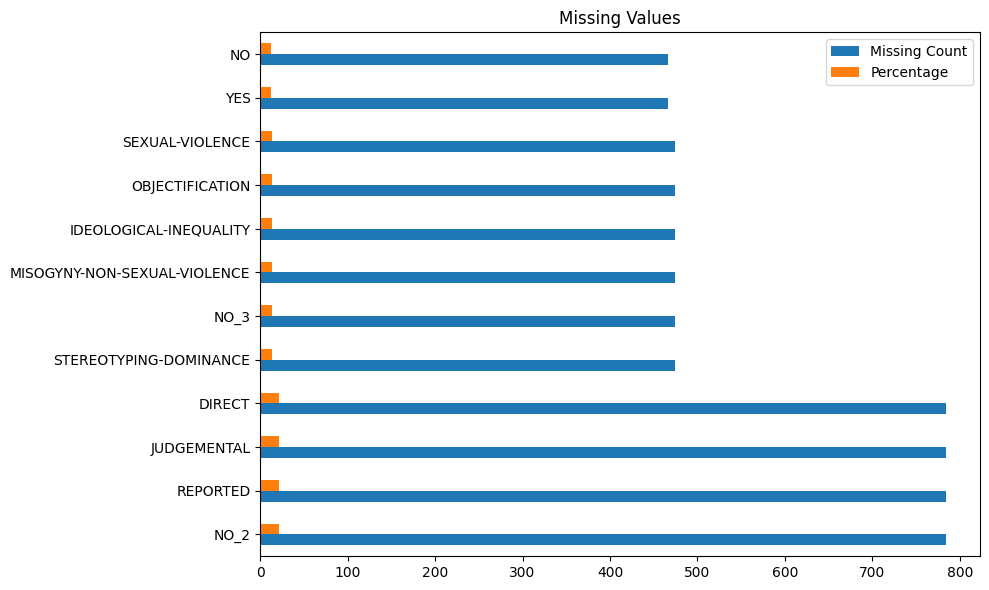

In [20]:
# Plot missing values
missing_df_es[missing_df_es['Missing Count'] > 0].plot(kind='barh', figsize=(10,6), title="Missing Values")
plt.tight_layout()
plt.show()

In [21]:
# Duplicate entries
duplicates_es = data_es.duplicated(subset=["tweet"])
print(f"Duplicate tweets: {duplicates_es.sum()}")

Duplicate tweets: 0


## II. Text-Specific Analysis

### Text Lengths

/var/folders/0s/37b847w521n_1v4k0x2wrrlr0000gn/T/ipykernel_38578/100705895.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_es['char_count'] = data_es['tweet'].str.len()
/var/folders/0s/37b847w521n_1v4k0x2wrrlr0000gn/T/ipykernel_38578/100705895.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_es['word_count'] = data_es['tweet'].str.split().apply(len)


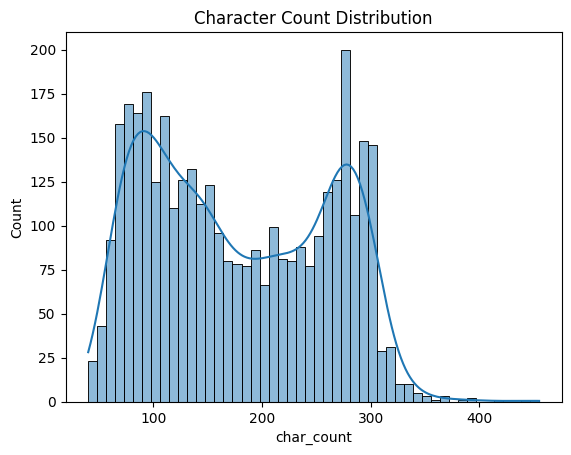

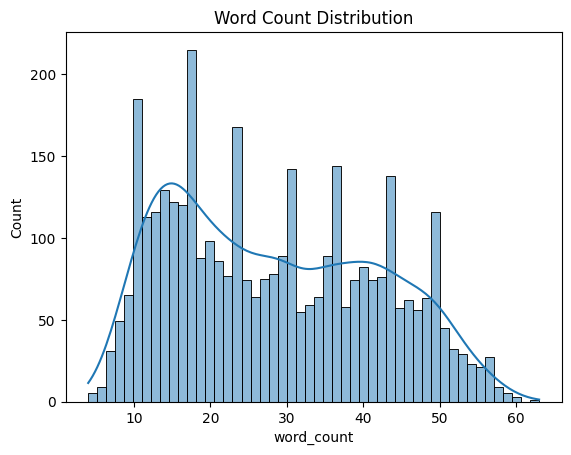

In [22]:
data_es['char_count'] = data_es['tweet'].str.len()
data_es['word_count'] = data_es['tweet'].str.split().apply(len)

# Histograms
sns.histplot(data_es['char_count'], bins=50, kde=True)
plt.title("Character Count Distribution")
plt.show()

sns.histplot(data_es['word_count'], bins=50, kde=True)
plt.title("Word Count Distribution")
plt.show()

### Vocabulary & Frequency

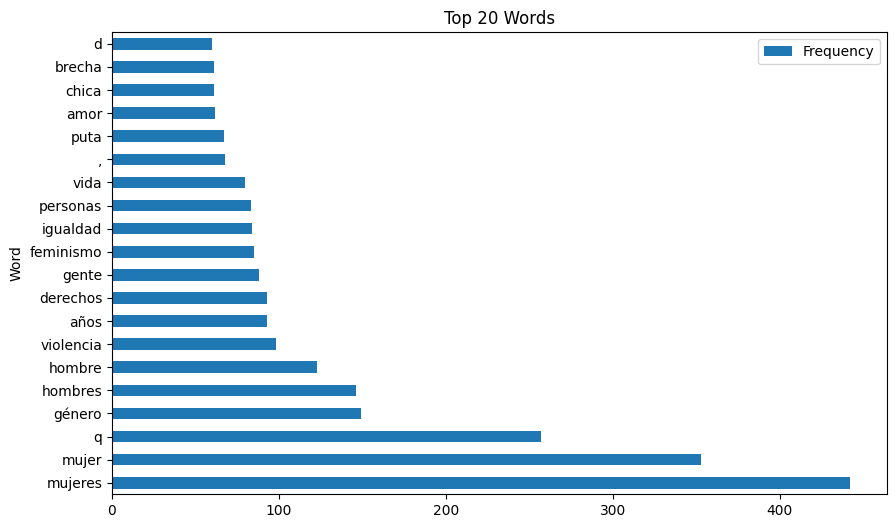

In [23]:
es_stop_custom = es_stop.union({'https','co'})
all_words_es = [word.lower() for tweet in data_es['tweet'] for word in tweet.split()]
filtered_words_es = [w for w in all_words_es if w not in es_stop_custom]

word_freq_es = Counter(filtered_words_es)

# Top 20 words
pd.DataFrame(word_freq_es.most_common(20), columns=["Word", "Frequency"]).plot(
    x='Word', y='Frequency', kind='barh', figsize=(10,6), title="Top 20 Words")
plt.show()

### N-Gram Analysis

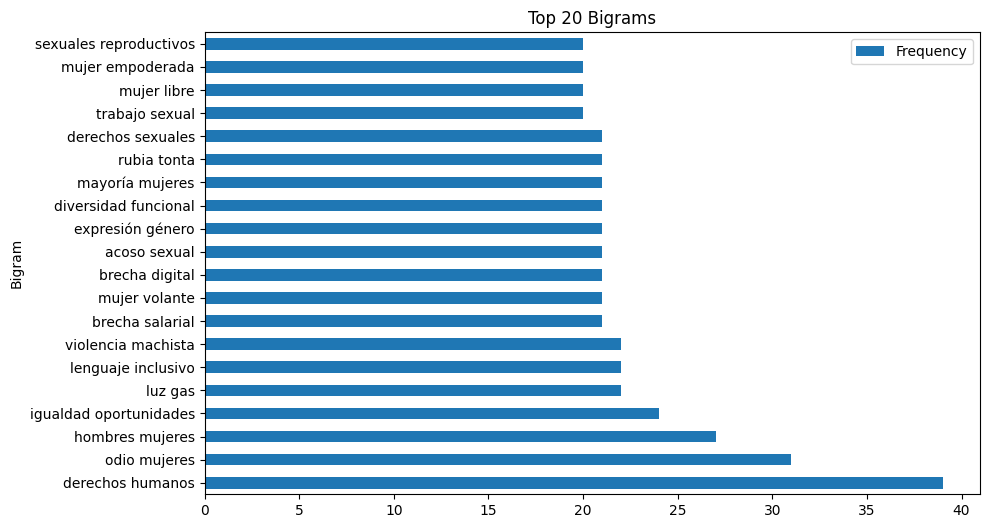

In [24]:
bigram_vectorizer_es = CountVectorizer(ngram_range=(2,2), stop_words=list(es_stop_custom))
X_bigrams_es = bigram_vectorizer_es.fit_transform(data_es['tweet'])
bigrams_es = bigram_vectorizer_es.get_feature_names_out()
bigram_freq_es = X_bigrams_es.sum(axis=0).A1
bigram_freq_df_es = pd.DataFrame({'Bigram': bigrams_es, 'Frequency': bigram_freq_es})
bigram_freq_df_es = bigram_freq_df_es[bigram_freq_df_es['Bigram'] != 'https co']
bigram_freq_df_es.sort_values(by='Frequency', ascending=False).head(20).plot(
    x='Bigram', y='Frequency', kind='barh', title='Top 20 Bigrams', figsize=(10,6))
plt.show()

### Punctuation & Casing

/var/folders/0s/37b847w521n_1v4k0x2wrrlr0000gn/T/ipykernel_38578/4189575226.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_es['punctuation_ratio'] = data_es['tweet'].apply(lambda x: sum([1 for c in x if c in string.punctuation]) / len(x) if len(x) > 0 else 0)
/var/folders/0s/37b847w521n_1v4k0x2wrrlr0000gn/T/ipykernel_38578/4189575226.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_es['uppercase_ratio'] = data_es['tweet'].apply(lambda x: sum(1 for c in x if c.isupper()) / len(x))


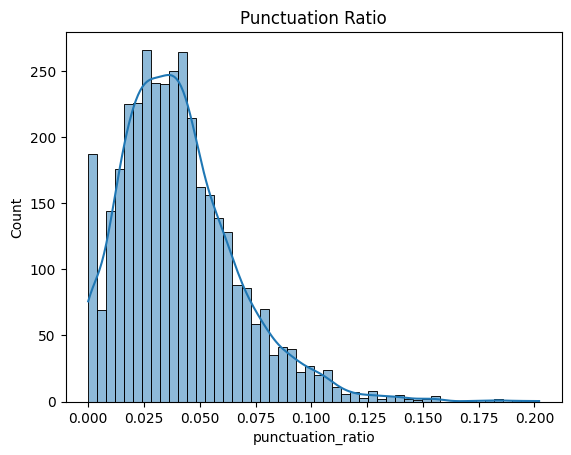

In [25]:
data_es['punctuation_ratio'] = data_es['tweet'].apply(lambda x: sum([1 for c in x if c in string.punctuation]) / len(x) if len(x) > 0 else 0)
data_es['uppercase_ratio'] = data_es['tweet'].apply(lambda x: sum(1 for c in x if c.isupper()) / len(x))

sns.histplot(data_es['punctuation_ratio'], bins=50, kde=True)
plt.title("Punctuation Ratio")
plt.show()

## III. Label-Specific-Analysis

### Label Distribution

JUDGEMENTAL                      228
REPORTED                         265
SEXUAL-VIOLENCE                  359
MISOGYNY-NON-SEXUAL-VIOLENCE     552
OBJECTIFICATION                  611
IDEOLOGICAL-INEQUALITY           632
DIRECT                           749
STEREOTYPING-DOMINANCE           810
YES                             1560
NO                              1634
dtype: object


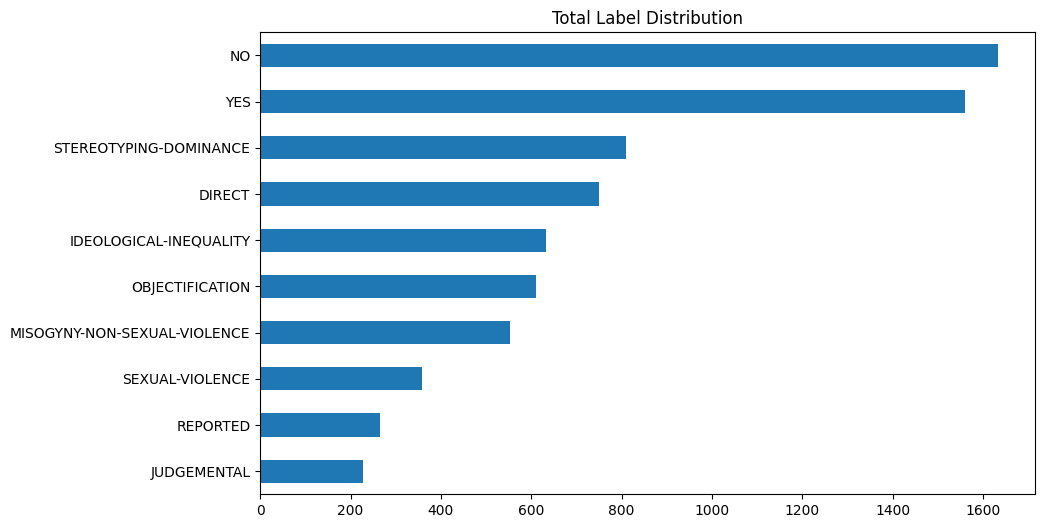

In [26]:
label_cols_total = ['YES', 'NO','DIRECT','REPORTED','JUDGEMENTAL',
              'IDEOLOGICAL-INEQUALITY','MISOGYNY-NON-SEXUAL-VIOLENCE',
              'STEREOTYPING-DOMINANCE','OBJECTIFICATION','SEXUAL-VIOLENCE']

print(data_es[label_cols_total].sum().sort_values())

data_es[label_cols_total].sum().sort_values().plot(kind='barh', figsize=(10,6), title="Total Label Distribution")
plt.show()

YES    1560
NO     1634
dtype: object


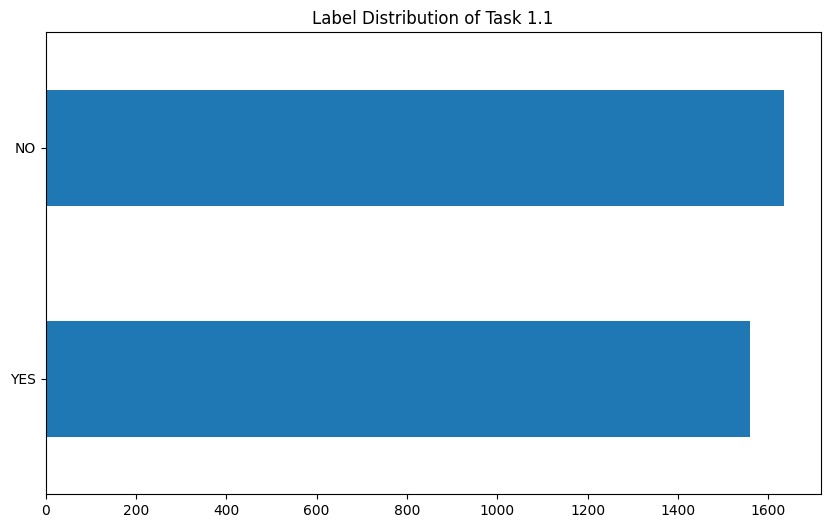

In [27]:
label_cols1_1 = ['YES', 'NO']

print(data_es[label_cols1_1].sum().sort_values())

data_es[label_cols1_1].sum().sort_values().plot(kind='barh', figsize=(10,6), title="Label Distribution of Task 1.1")
plt.show()

JUDGEMENTAL     228
REPORTED        265
DIRECT          749
NO_2           1634
dtype: object


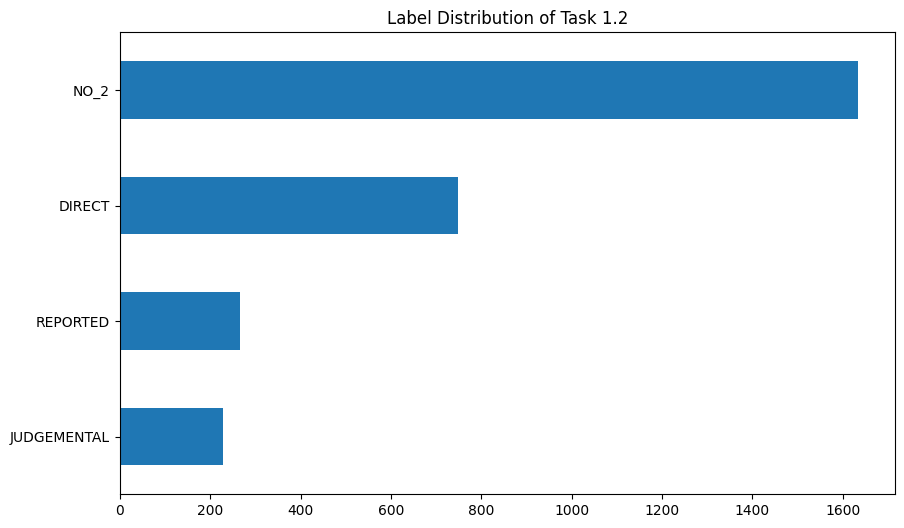

In [28]:
label_cols1_2 = ['NO_2','DIRECT','REPORTED','JUDGEMENTAL']

print(data_es[label_cols1_2].sum().sort_values())

data_es[label_cols1_2].sum().sort_values().plot(kind='barh', figsize=(10,6), title="Label Distribution of Task 1.2")
plt.show()

SEXUAL-VIOLENCE                  359
MISOGYNY-NON-SEXUAL-VIOLENCE     552
OBJECTIFICATION                  611
IDEOLOGICAL-INEQUALITY           632
STEREOTYPING-DOMINANCE           810
NO_3                            1634
dtype: object


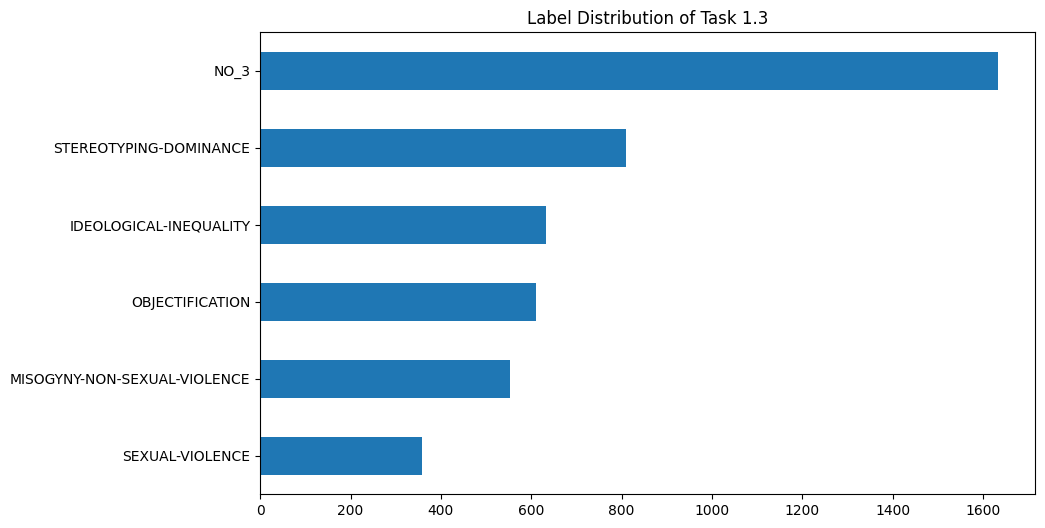

In [29]:
label_cols1_3 = ['NO_3',
              'IDEOLOGICAL-INEQUALITY','MISOGYNY-NON-SEXUAL-VIOLENCE',
              'STEREOTYPING-DOMINANCE','OBJECTIFICATION','SEXUAL-VIOLENCE']

print(data_es[label_cols1_3].sum().sort_values())

data_es[label_cols1_3].sum().sort_values().plot(kind='barh', figsize=(10,6), title="Label Distribution of Task 1.3")
plt.show()

### Label-Specific Text Length

In [30]:
def plot_distributions_by_labels(df, feature, label_list, title_prefix, n_cols=2):
    n = len(label_list)
    n_rows = math.ceil(n / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=True)
    axes = axes.flatten()  # Flatten in case it's a 2D array

    for i, label in enumerate(label_list):
        sns.histplot(df.loc[df[label] == 1, feature], bins=50, kde=True, ax=axes[i])
        axes[i].set_title(f"{title_prefix}: {label}")
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel("Frequency")
    
    # Turn off any unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

#### Character and Word Count Distributions by Label for Task 1.3

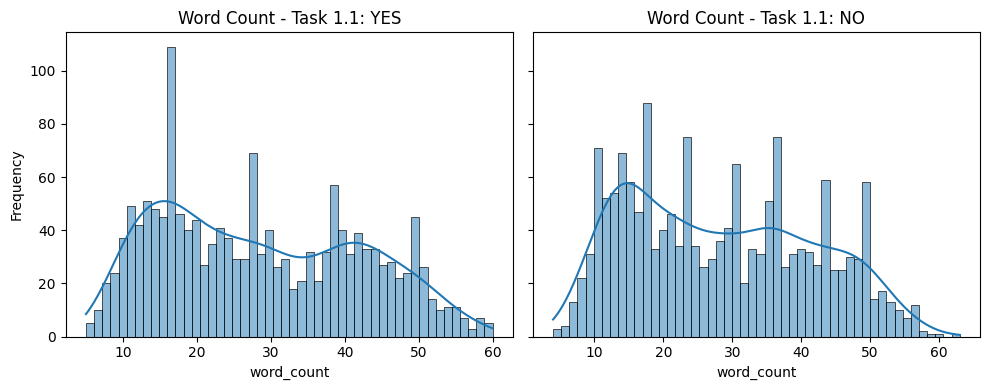

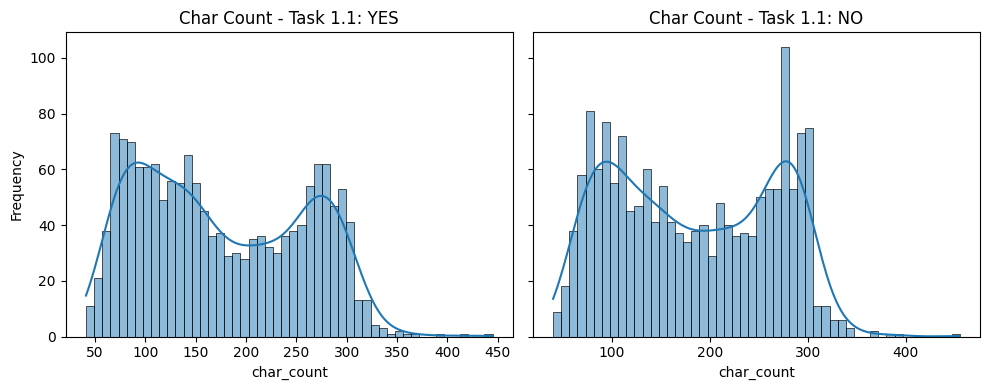

In [31]:
plot_distributions_by_labels(data_es, 'word_count', classes_task1_1, "Word Count - Task 1.1")
plot_distributions_by_labels(data_es, 'char_count', classes_task1_1, "Char Count - Task 1.1")

#### Character and Word Count Distributions by Label for Task 1.2

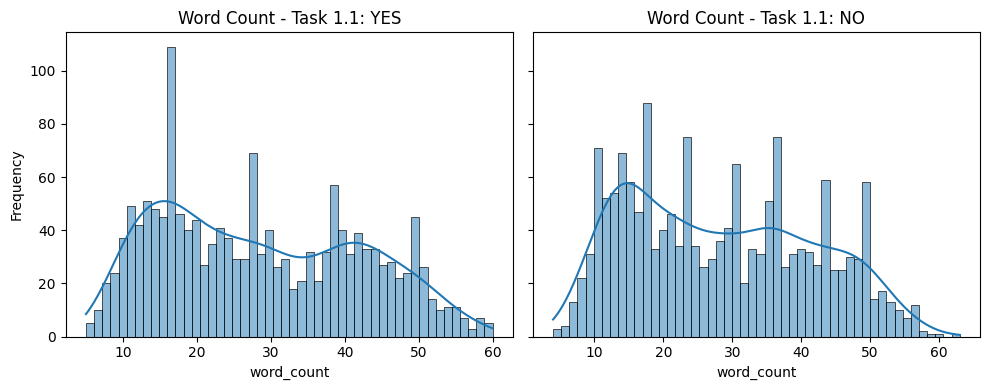

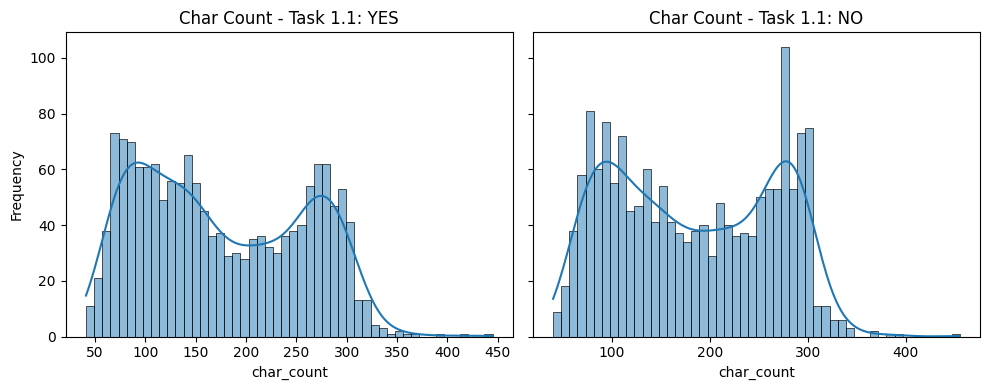

In [32]:
plot_distributions_by_labels(data_es, 'word_count', classes_task1_1, "Word Count - Task 1.1")
plot_distributions_by_labels(data_es, 'char_count', classes_task1_1, "Char Count - Task 1.1")

#### Character and Word Count Distributions by Label for Task 1.3

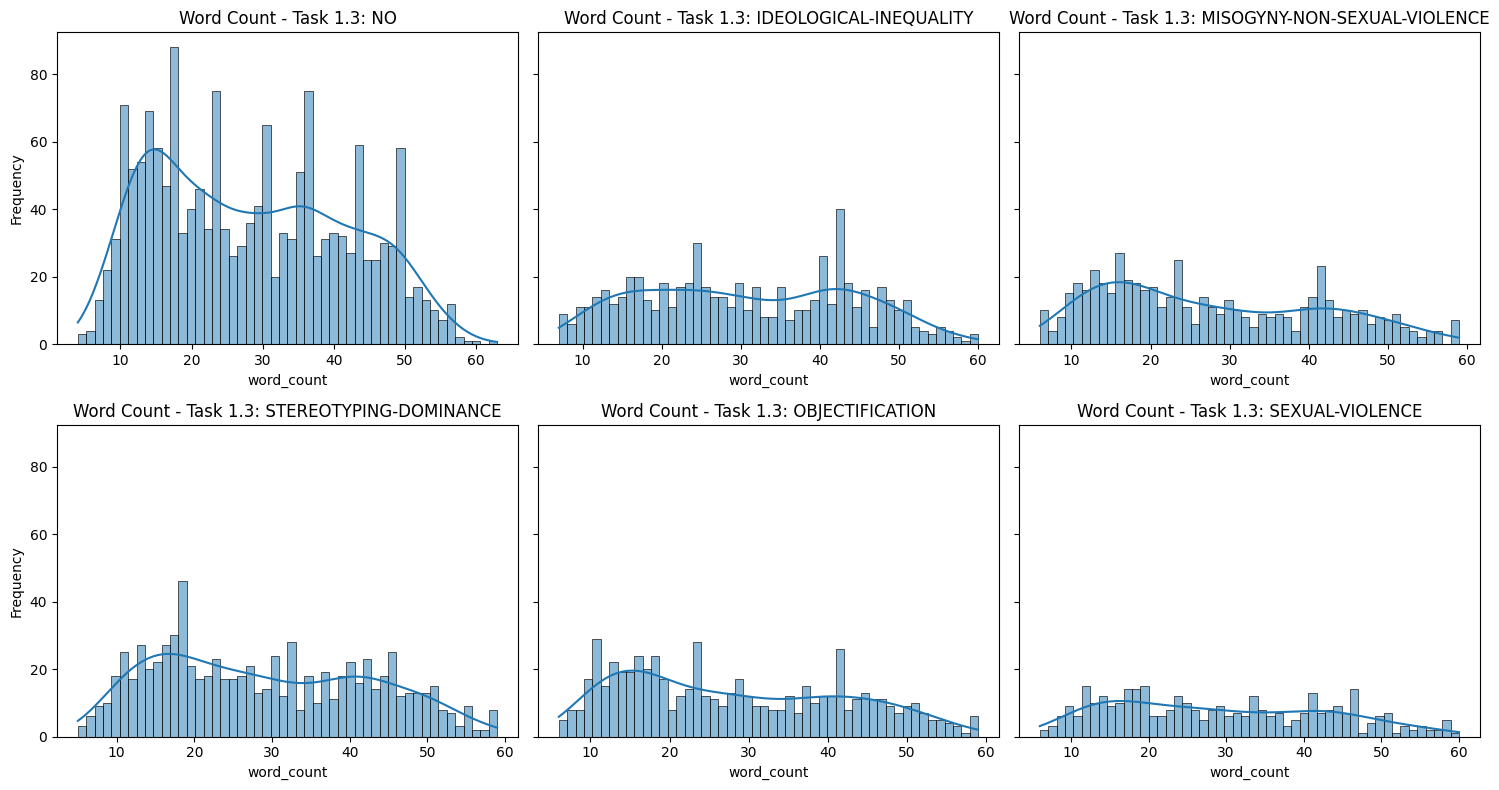

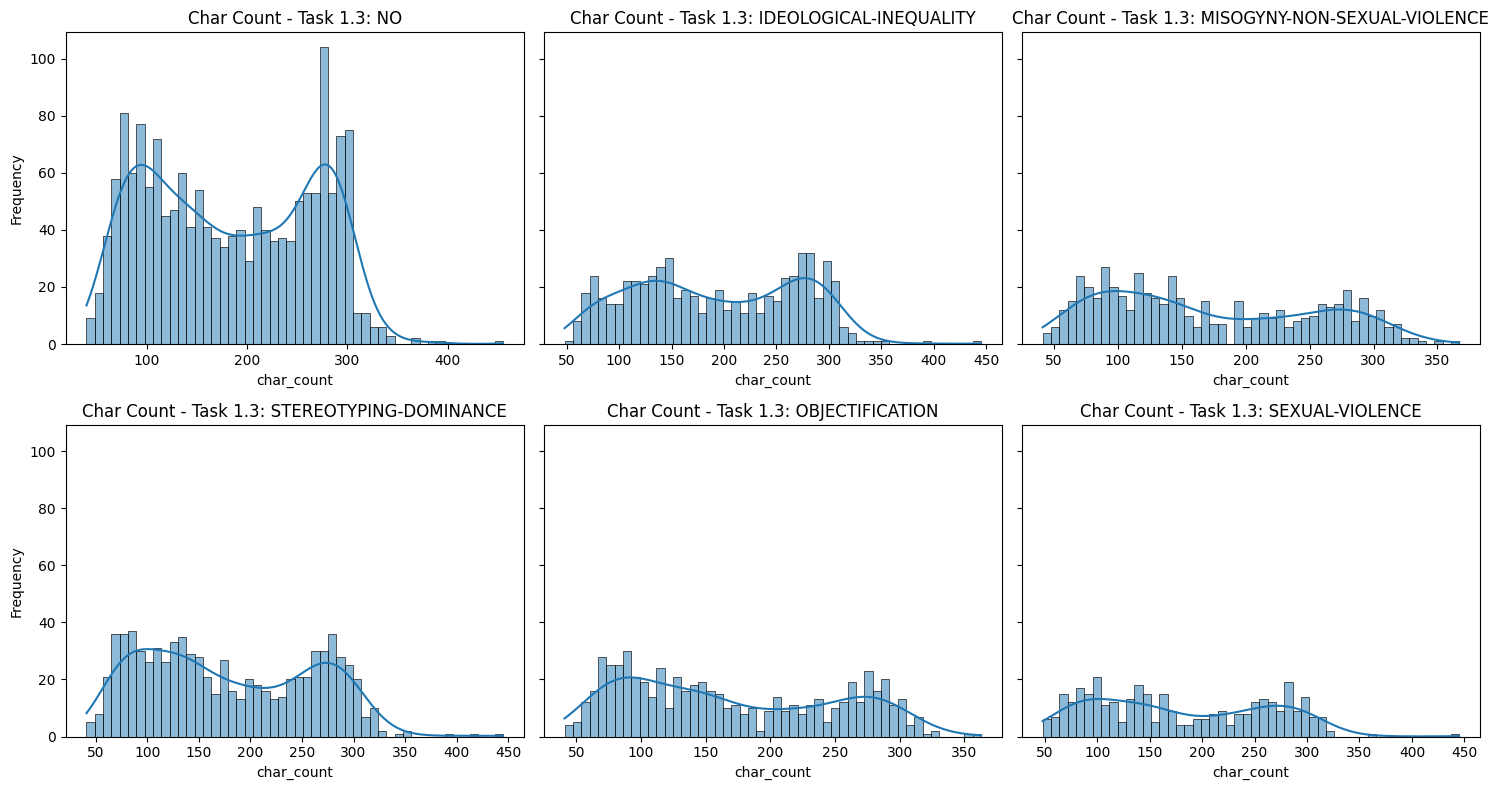

In [33]:
plot_distributions_by_labels(data_es, 'word_count', classes_task1_3, "Word Count - Task 1.3", n_cols=3)
plot_distributions_by_labels(data_es, 'char_count', classes_task1_3, "Char Count - Task 1.3", n_cols=3)

## IV. Word Clouds and Topic Modeling

### Word Cloud

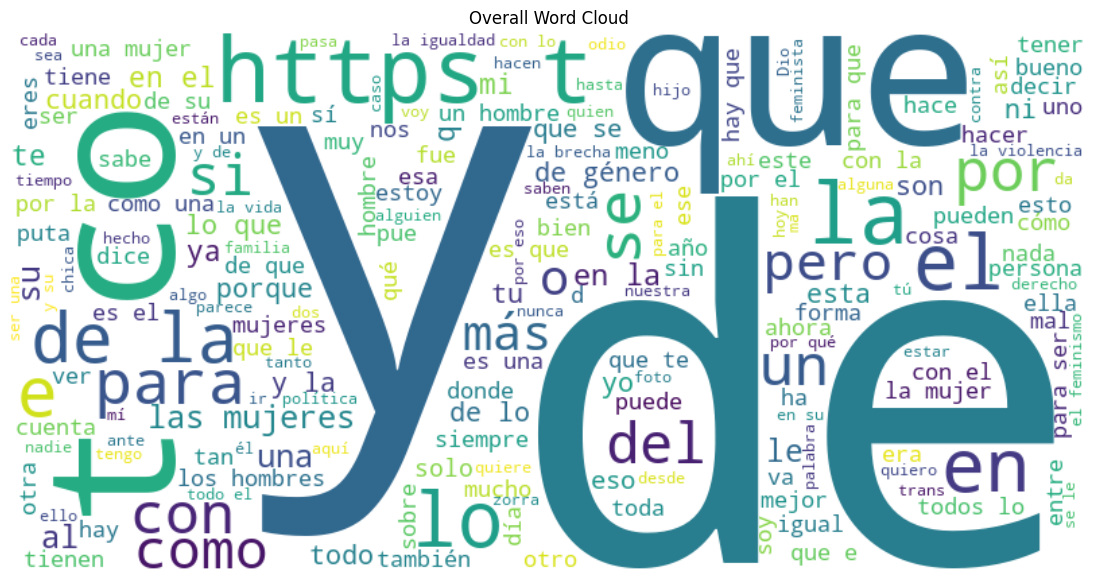

In [34]:
text_es = ' '.join(data_es['tweet'].astype(str).tolist())
wordcloud_es = WordCloud(width=800, height=400, background_color='white').generate(text_es)
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud_es, interpolation='bilinear')
plt.axis('off')
plt.title("Overall Word Cloud")
plt.show()

### Topic Modeling

In [35]:
tfidf_vectorizer_es = TfidfVectorizer(max_df=0.95, min_df=2, stop_words=list(es_stop_custom))
X_tfidf_es = tfidf_vectorizer_es.fit_transform(data_es['tweet'])

lda_es = LatentDirichletAllocation(n_components=5, random_state=0)
lda_es.fit(X_tfidf_es)

# Top words per topic
def print_top_words(model, feature_names, n_top_words=10):
    for idx, topic in enumerate(model.components_):
        print(f"Topic {idx + 1}: ", ", ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))

print_top_words(lda_es, tfidf_vectorizer_es.get_feature_names_out())

Topic 1:  mujer, mujeres, hombres, depresión, volante, gente, persona, trabajo, cosas, puta
Topic 2:  mujeres, puta, mujer, hombres, hombre, feminismo, género, gente, trans, falso
Topic 3:  mujer, mujeres, hombre, violencia, quiero, vida, gustaría, follar, género, zorra
Topic 4:  mujeres, género, discriminación, hombres, doble, violencia, cuerpo, femenino, polla, amor
Topic 5:  mujer, mujeres, género, falda, corta, alta, chica, frente, culo, lengua


## V. Embedding Visualization

### t-SNE

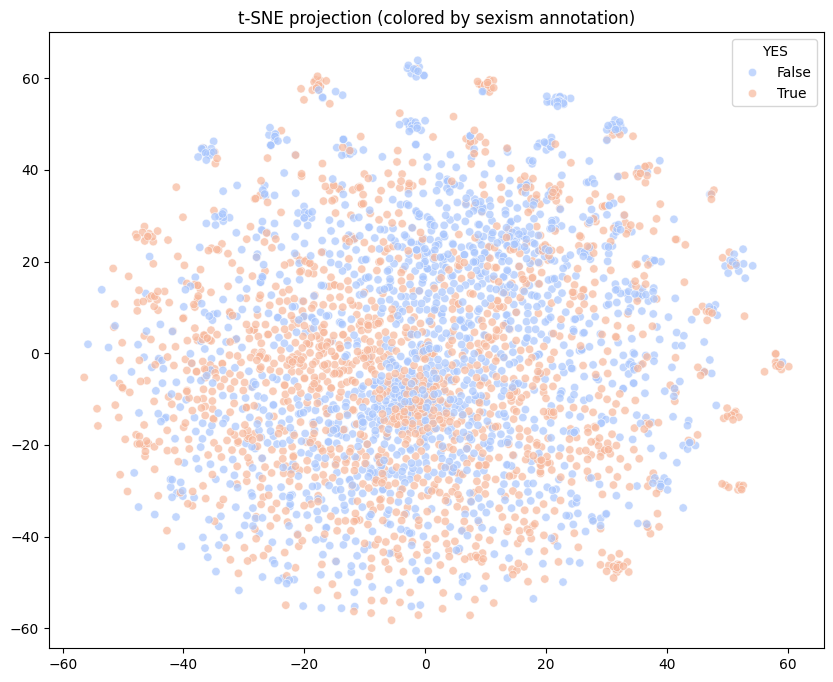

In [36]:
tfidf_es = TfidfVectorizer(max_features=500)
X_es = tfidf_es.fit_transform(data_es['tweet'])

tsne_es = TSNE(n_components=2, random_state=0)
X_embedded_es = tsne_es.fit_transform(X_es.toarray())

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_embedded_es[:, 0], y=X_embedded_es[:, 1],
    hue=data_es['YES'],
    palette='coolwarm',
    alpha=0.7
)
plt.title('t-SNE projection (colored by sexism annotation)')
plt.show()

### UMAP

/opt/miniconda3/envs/nlp/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/miniconda3/envs/nlp/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


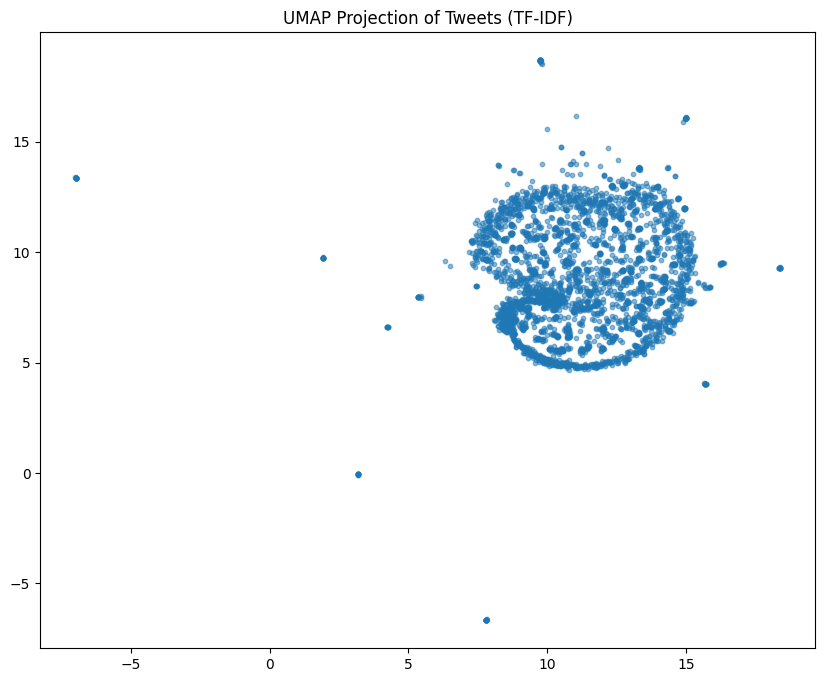

In [37]:
tfidf_es = TfidfVectorizer(max_features=1000, stop_words=list(es_stop_custom))
X_tfidf_es = tfidf_es.fit_transform(data_es['tweet'])

# Apply UMAP
reducer_es = umap.UMAP(random_state=42)
X_umap_es = reducer_es.fit_transform(X_tfidf_es)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(X_umap_es[:, 0], X_umap_es[:, 1], alpha=0.5, s=10)
plt.title("UMAP Projection of Tweets (TF-IDF)")
plt.show()

# Data Exploration (English)

In [38]:
# Get data for spanish tweets
data_en = data[data['lang'] == 'en']

## I. Statistics

In [39]:
# Dataset overview
print(f"Number of samples: {len(data_en)}")
print(f"Number of columns: {data_en.shape[1]}")
print(data_en.dtypes)

Number of samples: 3260
Number of columns: 37
id                                    object
id_EXIST                              object
lang                                  object
tweet                                 object
number_annotators                      int64
annotators                            object
gender_annotators                     object
age_annotators                        object
ethnicities_annotators                object
study_levels_annotators               object
countries_annotators                  object
labels_task1_1                        object
labels_task1_2                        object
labels_task1_3                        object
split                                 object
YES                                   object
NO                                    object
YES_freq                             float64
NO_freq                              float64
NO_2                                  object
DIRECT                                object
REPORTED 

In [40]:
# Missing values
missing_en = data_en.isnull().sum().sort_values(ascending=False)
missing_percent_en = (missing_en / len(data_en)) * 100
missing_df_en = pd.DataFrame({'Missing Count': missing_en, 'Percentage': missing_percent_en})
missing_df_en

,Missing Count,Percentage
NO_2,640,19.631902
REPORTED,640,19.631902
JUDGEMENTAL,640,19.631902
DIRECT,640,19.631902
STEREOTYPING-DOMINANCE,396,12.147239
NO_3,396,12.147239
MISOGYNY-NON-SEXUAL-VIOLENCE,396,12.147239
IDEOLOGICAL-INEQUALITY,396,12.147239
OBJECTIFICATION,396,12.147239
SEXUAL-VIOLENCE,396,12.147239


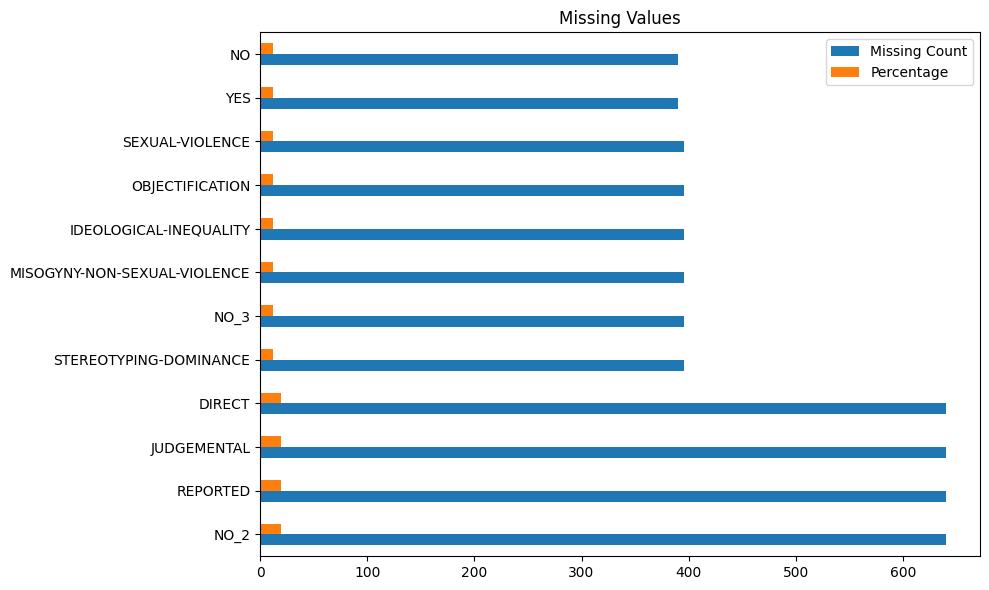

In [41]:
# Plot missing values
missing_df_en[missing_df_en['Missing Count'] > 0].plot(kind='barh', figsize=(10,6), title="Missing Values")
plt.tight_layout()
plt.show()

In [42]:
# Duplicate entries
duplicates_en = data_en.duplicated(subset=["tweet"])
print(f"Duplicate tweets: {duplicates_en.sum()}")

Duplicate tweets: 0


## II. Text-Specific Analysis

### Text Lengths

/var/folders/0s/37b847w521n_1v4k0x2wrrlr0000gn/T/ipykernel_38578/2385636094.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_en['char_count'] = data_en['tweet'].str.len()
/var/folders/0s/37b847w521n_1v4k0x2wrrlr0000gn/T/ipykernel_38578/2385636094.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_en['word_count'] = data_en['tweet'].str.split().apply(len)


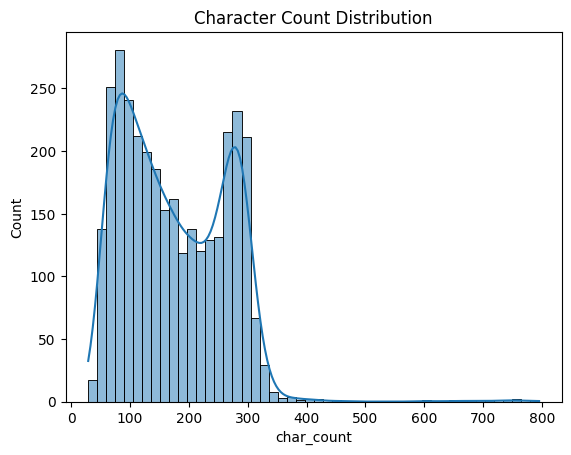

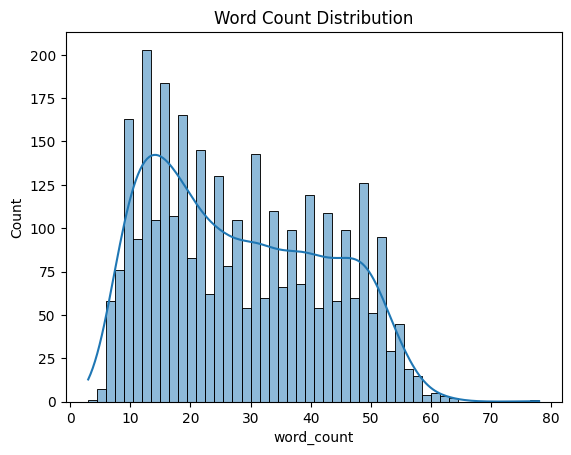

In [43]:
data_en['char_count'] = data_en['tweet'].str.len()
data_en['word_count'] = data_en['tweet'].str.split().apply(len)

# Histograms
sns.histplot(data_en['char_count'], bins=50, kde=True)
plt.title("Character Count Distribution")
plt.show()

sns.histplot(data_en['word_count'], bins=50, kde=True)
plt.title("Word Count Distribution")
plt.show()

### Vocabulary & Frequency

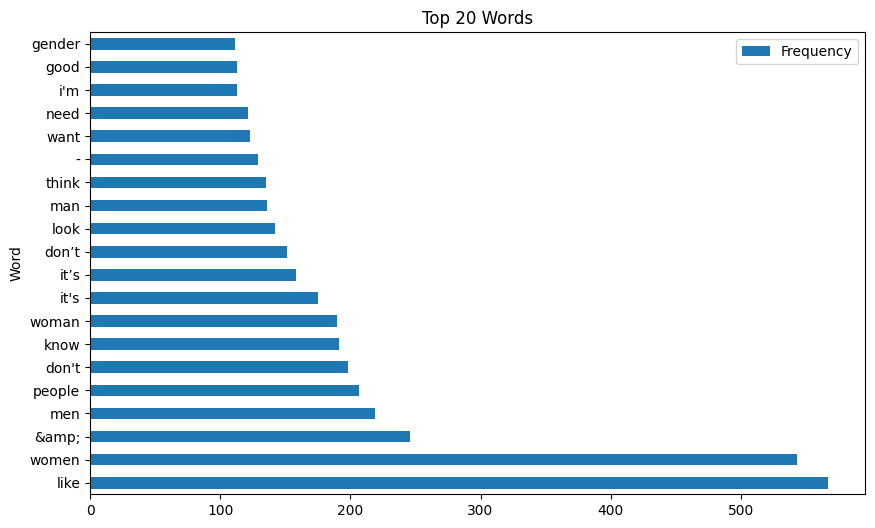

In [44]:
stop_words_en = set(stopwords.words('english'))

all_words_en = [word.lower() for tweet in data_en['tweet'] for word in tweet.split()]
filtered_words_en = [w for w in all_words_en if w not in en_stop]

word_freq_en = Counter(filtered_words_en)

# Top 20 words
pd.DataFrame(word_freq_en.most_common(20), columns=["Word", "Frequency"]).plot(
    x='Word', y='Frequency', kind='barh', figsize=(10,6), title="Top 20 Words")
plt.show()

### N-Gram Analysis

/opt/miniconda3/envs/nlp/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ll', 've'] not in stop_words.
  warnings.warn(


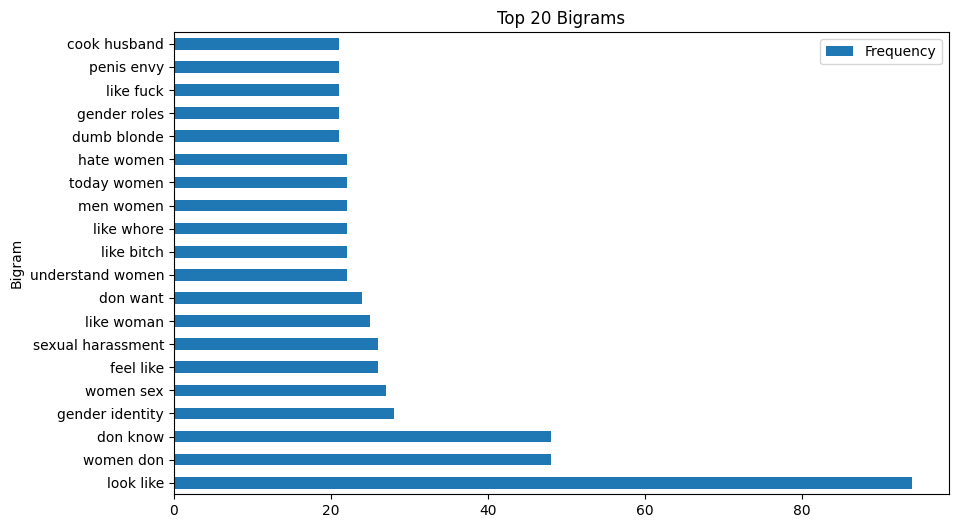

In [45]:
en_stop_custom = en_stop.union({'https','co'})
bigram_vectorizer_en = CountVectorizer(ngram_range=(2,2), stop_words=list(en_stop_custom))
X_bigrams_en = bigram_vectorizer_en.fit_transform(data_en['tweet'])
bigrams_en = bigram_vectorizer_en.get_feature_names_out()
bigram_freq_en = X_bigrams_en.sum(axis=0).A1
bigram_freq_df_en = pd.DataFrame({'Bigram': bigrams_en, 'Frequency': bigram_freq_en})
bigram_freq_df_en.sort_values(by='Frequency', ascending=False).head(20).plot(
    x='Bigram', y='Frequency', kind='barh', title='Top 20 Bigrams', figsize=(10,6))
plt.show()

### Punctuation & Casing

/var/folders/0s/37b847w521n_1v4k0x2wrrlr0000gn/T/ipykernel_38578/1644579901.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_en['punctuation_ratio'] = data_en['tweet'].apply(lambda x: sum([1 for c in x if c in string.punctuation]) / len(x) if len(x) > 0 else 0)
/var/folders/0s/37b847w521n_1v4k0x2wrrlr0000gn/T/ipykernel_38578/1644579901.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_en['uppercase_ratio'] = data_en['tweet'].apply(lambda x: sum(1 for c in x if c.isupper()) / len(x))


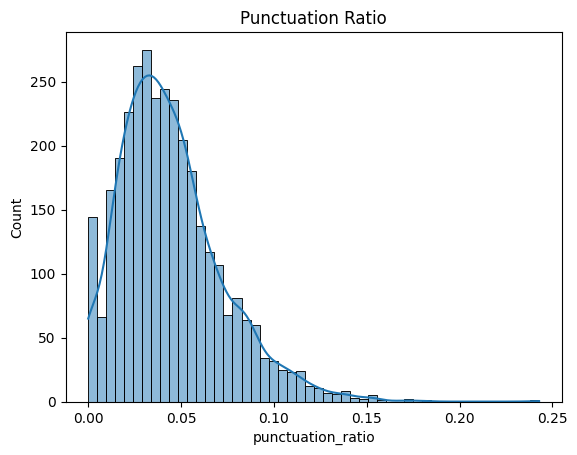

In [46]:
data_en['punctuation_ratio'] = data_en['tweet'].apply(lambda x: sum([1 for c in x if c in string.punctuation]) / len(x) if len(x) > 0 else 0)
data_en['uppercase_ratio'] = data_en['tweet'].apply(lambda x: sum(1 for c in x if c.isupper()) / len(x))

sns.histplot(data_en['punctuation_ratio'], bins=50, kde=True)
plt.title("Punctuation Ratio")
plt.show()

## III. Label-Specific-Analysis

### Label Distribution

JUDGEMENTAL                      228
REPORTED                         265
SEXUAL-VIOLENCE                  359
MISOGYNY-NON-SEXUAL-VIOLENCE     552
OBJECTIFICATION                  611
IDEOLOGICAL-INEQUALITY           632
DIRECT                           749
STEREOTYPING-DOMINANCE           810
YES                             1560
NO                              1634
dtype: object


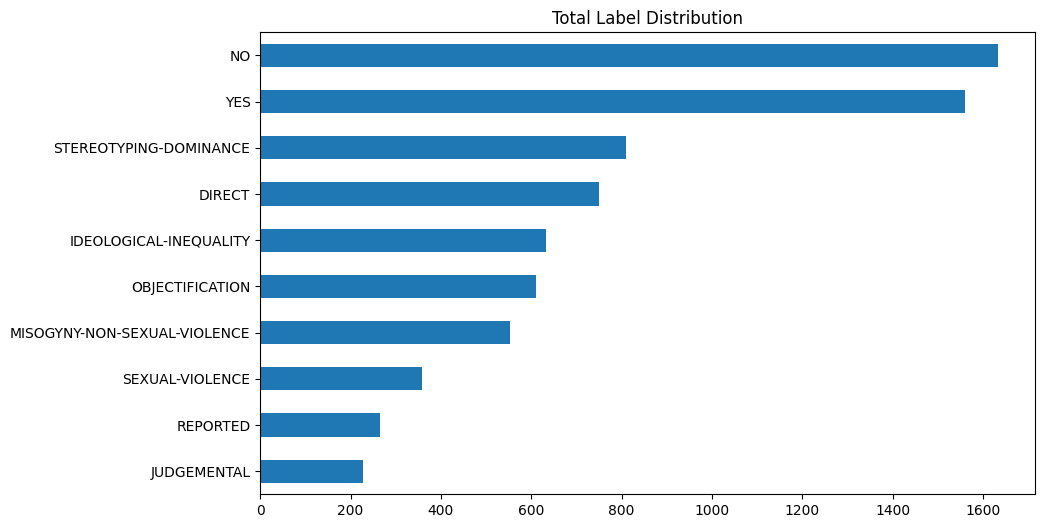

In [47]:
label_cols_total = ['YES', 'NO','DIRECT','REPORTED','JUDGEMENTAL',
              'IDEOLOGICAL-INEQUALITY','MISOGYNY-NON-SEXUAL-VIOLENCE',
              'STEREOTYPING-DOMINANCE','OBJECTIFICATION','SEXUAL-VIOLENCE']

print(data_es[label_cols_total].sum().sort_values())

data_es[label_cols_total].sum().sort_values().plot(kind='barh', figsize=(10,6), title="Total Label Distribution")
plt.show()

YES    1560
NO     1634
dtype: object


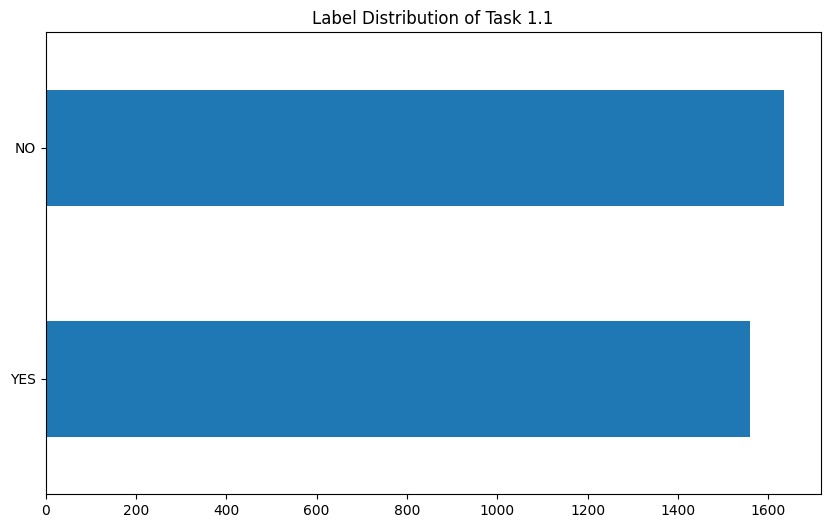

In [48]:
label_cols1_1 = ['YES', 'NO']

print(data_es[label_cols1_1].sum().sort_values())

data_es[label_cols1_1].sum().sort_values().plot(kind='barh', figsize=(10,6), title="Label Distribution of Task 1.1")
plt.show()

JUDGEMENTAL     228
REPORTED        265
DIRECT          749
NO_2           1634
dtype: object


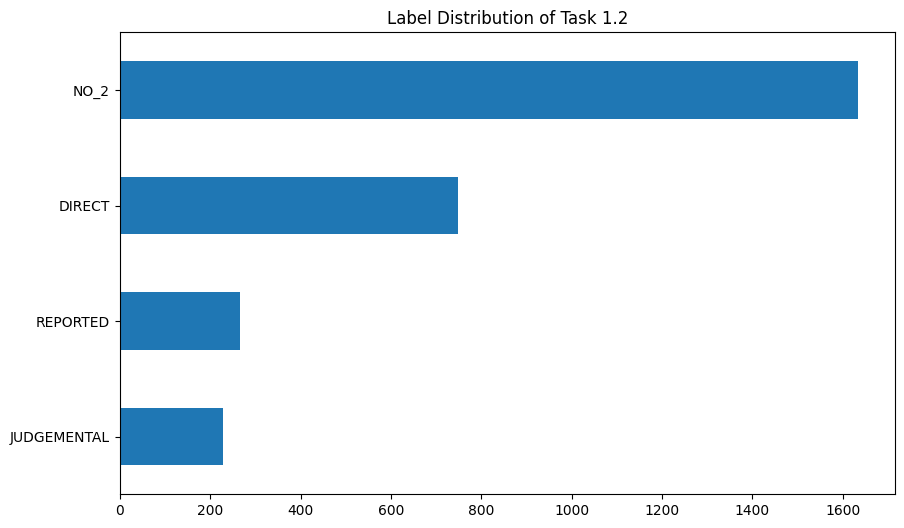

In [49]:
label_cols1_2 = ['NO_2','DIRECT','REPORTED','JUDGEMENTAL']

print(data_es[label_cols1_2].sum().sort_values())

data_es[label_cols1_2].sum().sort_values().plot(kind='barh', figsize=(10,6), title="Label Distribution of Task 1.2")
plt.show()

SEXUAL-VIOLENCE                  359
MISOGYNY-NON-SEXUAL-VIOLENCE     552
OBJECTIFICATION                  611
IDEOLOGICAL-INEQUALITY           632
STEREOTYPING-DOMINANCE           810
NO_3                            1634
dtype: object


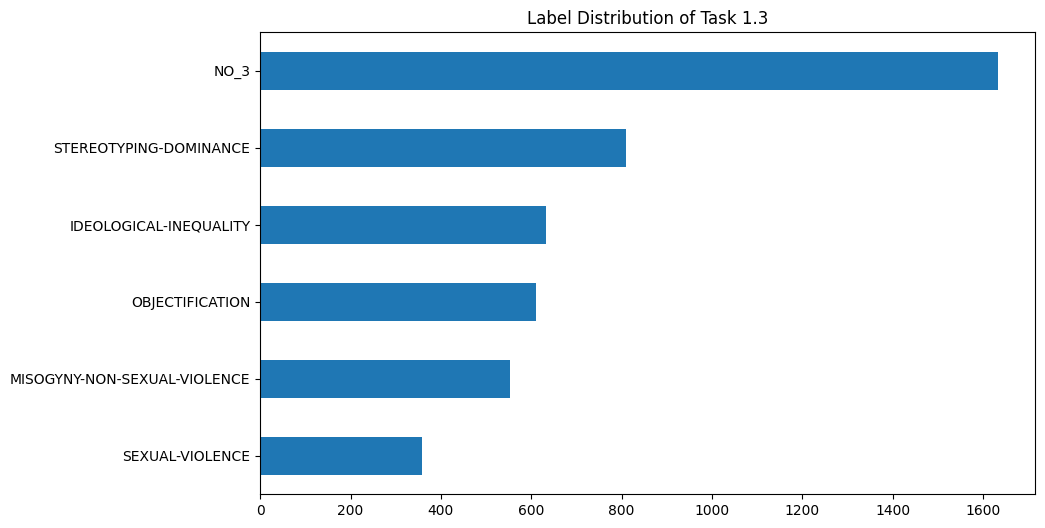

In [50]:
label_cols1_3 = ['NO_3',
              'IDEOLOGICAL-INEQUALITY','MISOGYNY-NON-SEXUAL-VIOLENCE',
              'STEREOTYPING-DOMINANCE','OBJECTIFICATION','SEXUAL-VIOLENCE']

print(data_es[label_cols1_3].sum().sort_values())

data_es[label_cols1_3].sum().sort_values().plot(kind='barh', figsize=(10,6), title="Label Distribution of Task 1.3")
plt.show()

### Label-Specific Text Length

In [51]:
def plot_distributions_by_labels(df, feature, label_list, title_prefix, n_cols=2):
    n = len(label_list)
    n_rows = math.ceil(n / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=True)
    axes = axes.flatten()  # Flatten in case it's a 2D array

    for i, label in enumerate(label_list):
        sns.histplot(df.loc[df[label] == 1, feature], bins=50, kde=True, ax=axes[i])
        axes[i].set_title(f"{title_prefix}: {label}")
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel("Frequency")
    
    # Turn off any unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

#### Character and Word Count Distributions by Label for Task 1.3

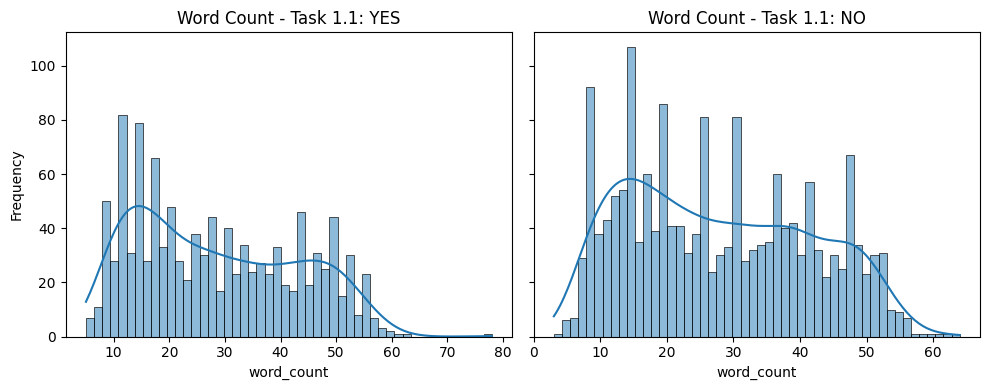

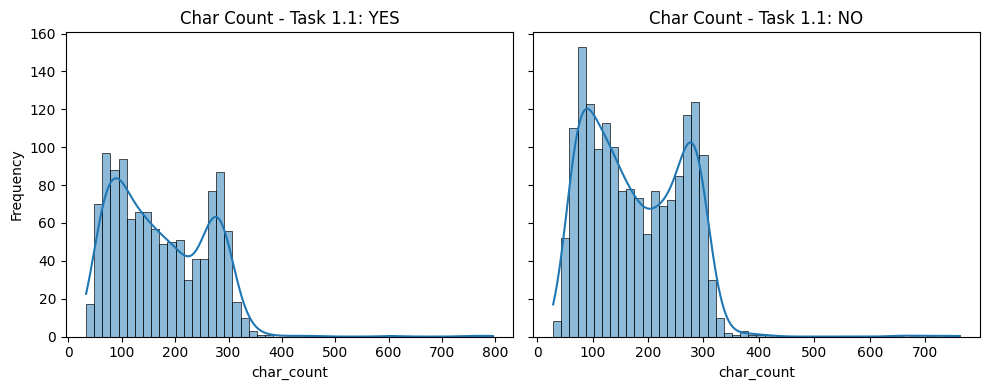

In [52]:
plot_distributions_by_labels(data_en, 'word_count', classes_task1_1, "Word Count - Task 1.1")
plot_distributions_by_labels(data_en, 'char_count', classes_task1_1, "Char Count - Task 1.1")

#### Character and Word Count Distributions by Label for Task 1.2

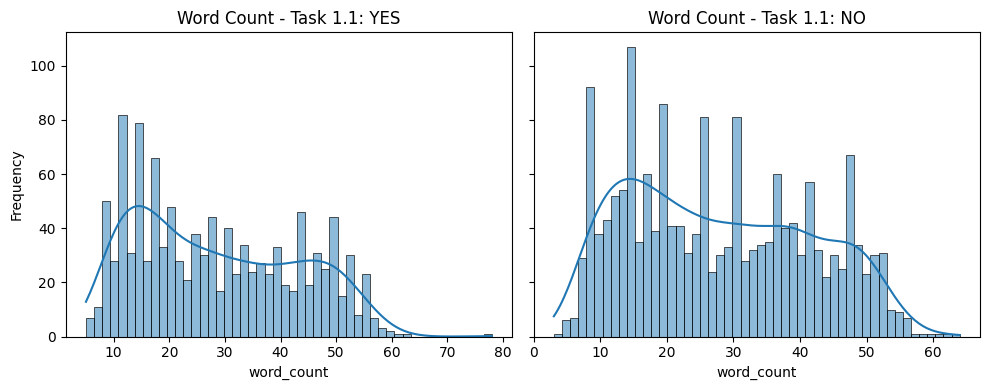

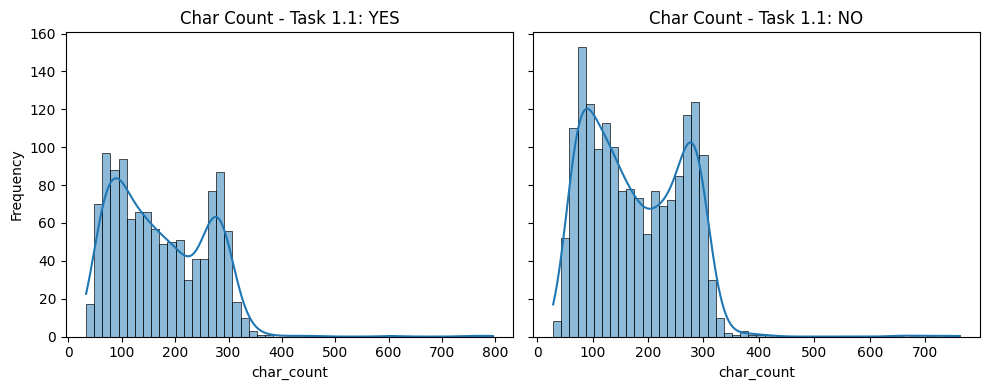

In [53]:
plot_distributions_by_labels(data_en, 'word_count', classes_task1_1, "Word Count - Task 1.1")
plot_distributions_by_labels(data_en, 'char_count', classes_task1_1, "Char Count - Task 1.1")

#### Character and Word Count Distributions by Label for Task 1.3

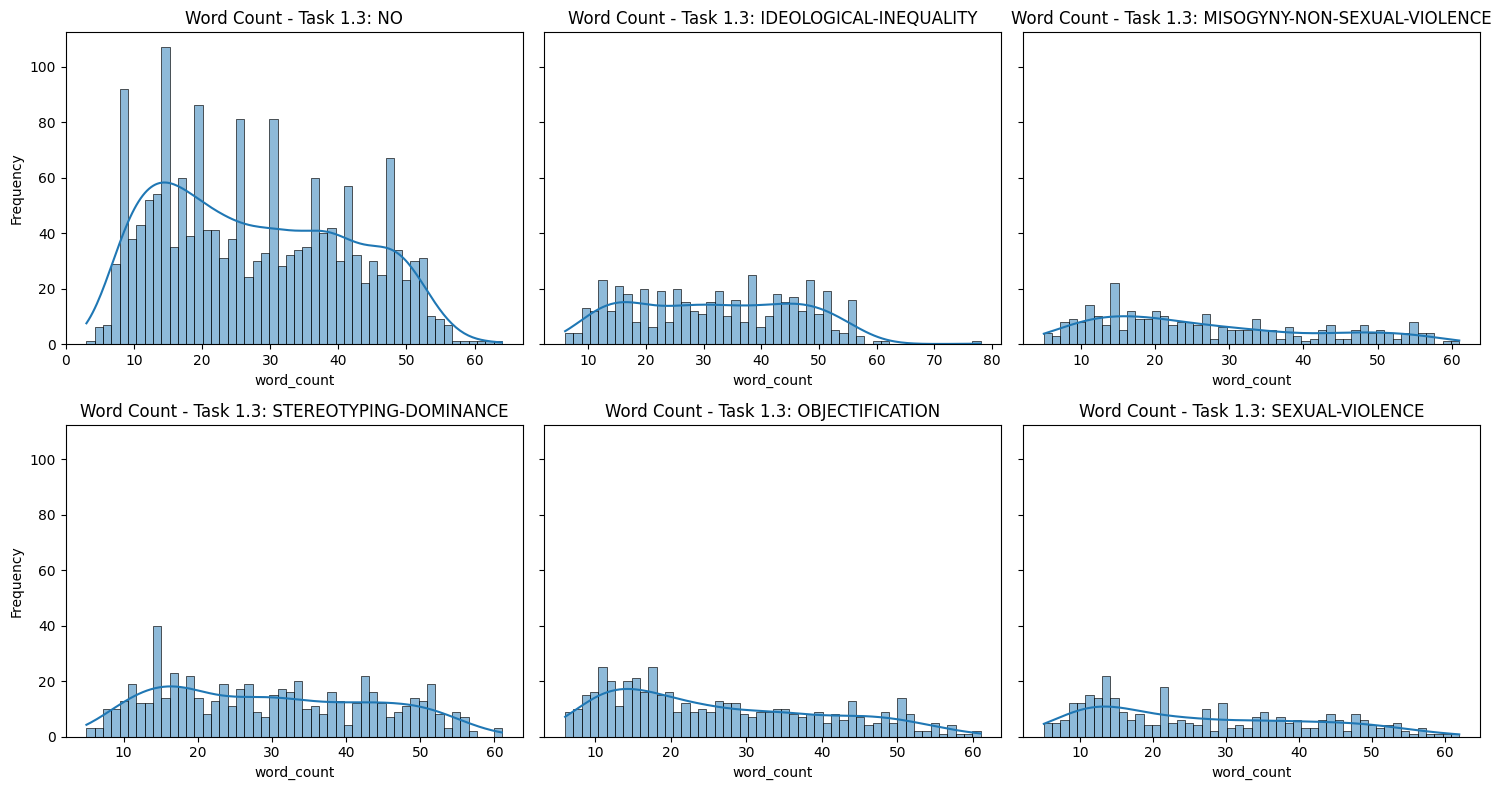

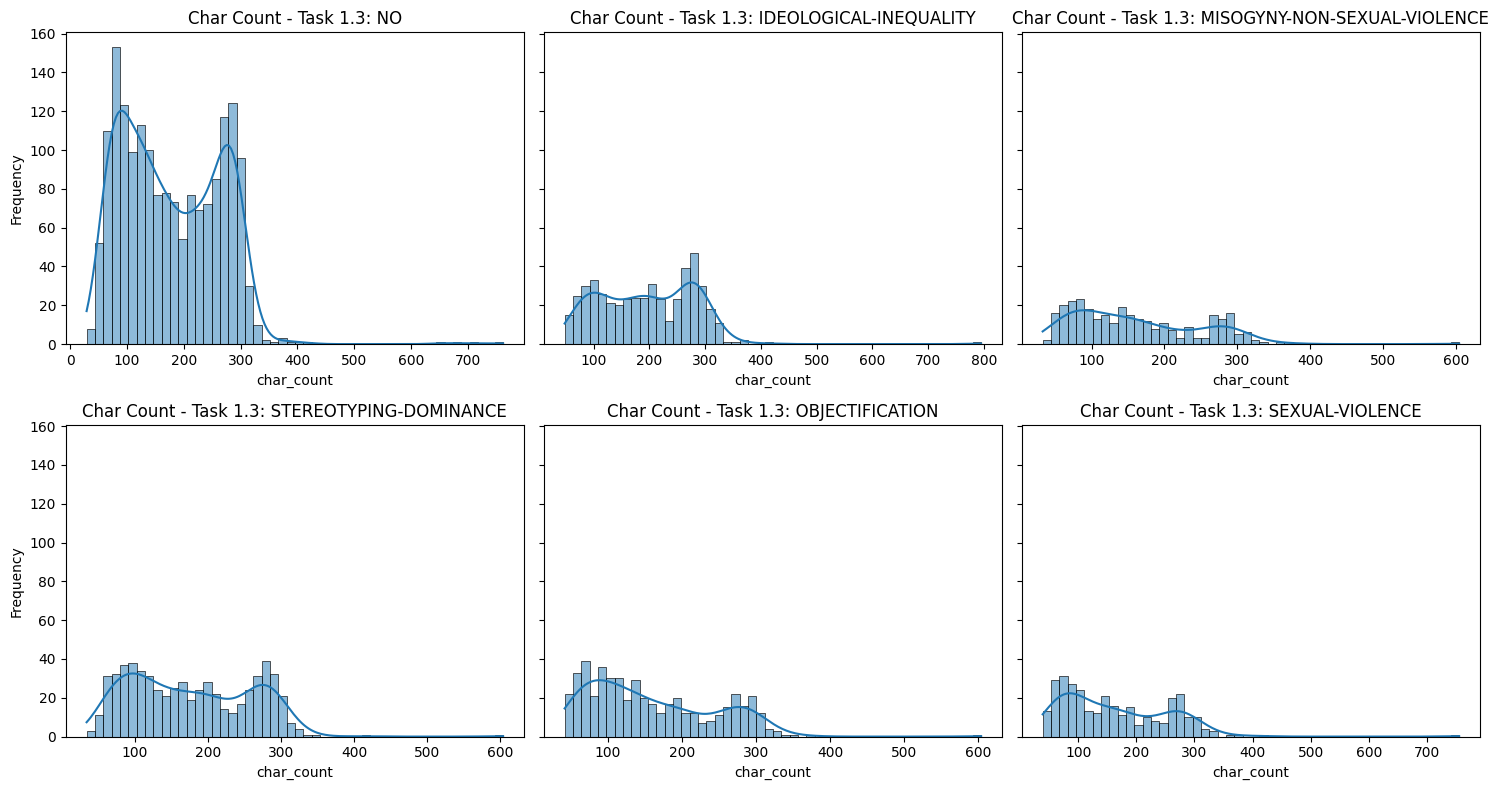

In [54]:
plot_distributions_by_labels(data_en, 'word_count', classes_task1_3, "Word Count - Task 1.3", n_cols=3)
plot_distributions_by_labels(data_en, 'char_count', classes_task1_3, "Char Count - Task 1.3", n_cols=3)

### Label Distribution

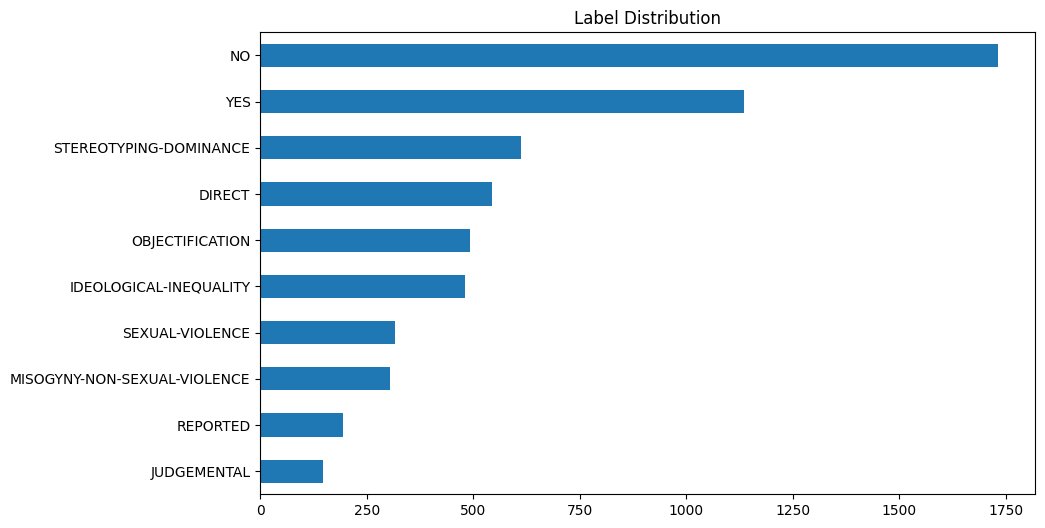

In [55]:
label_cols = ['YES', 'NO','DIRECT','REPORTED','JUDGEMENTAL',
              'IDEOLOGICAL-INEQUALITY','MISOGYNY-NON-SEXUAL-VIOLENCE',
              'STEREOTYPING-DOMINANCE','OBJECTIFICATION','SEXUAL-VIOLENCE']

data_en[label_cols].sum().sort_values().plot(kind='barh', figsize=(10,6), title="Label Distribution")
plt.show()

## IV. Word Clouds and Topic Modeling

### Word Cloud

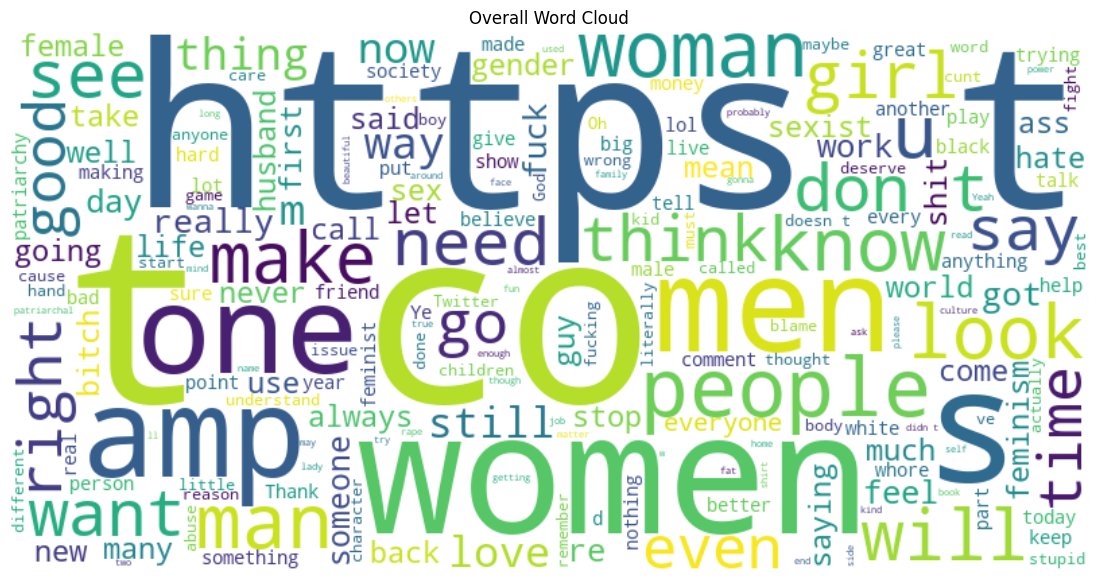

In [56]:
text_en = ' '.join(data_en['tweet'].astype(str).tolist())
wordcloud_en = WordCloud(width=800, height=400, background_color='white').generate(text_en)
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud_en, interpolation='bilinear')
plt.axis('off')
plt.title("Overall Word Cloud")
plt.show()

### Topic Modeling

In [57]:
tfidf_vectorizer_en = TfidfVectorizer(max_df=0.95, min_df=2, stop_words=list(en_stop_custom))
X_tfidf_en = tfidf_vectorizer_en.fit_transform(data_en['tweet'])

lda_en = LatentDirichletAllocation(n_components=5, random_state=0)
lda_en.fit(X_tfidf_en)

# Top words per topic
def print_top_words(model, feature_names, n_top_words=10):
    for idx, topic in enumerate(model.components_):
        print(f"Topic {idx + 1}: ", ", ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))

print_top_words(lda_en, tfidf_vectorizer_en.get_feature_names_out())

/opt/miniconda3/envs/nlp/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ll', 've'] not in stop_words.
  warnings.warn(


Topic 1:  like, women, day, people, amp, dumb, woman, men, stop, don
Topic 2:  women, don, men, like, want, know, think, people, hate, time
Topic 3:  women, fuck, like, men, don, man, woman, gender, husband, sexual
Topic 4:  women, like, bitch, don, woman, man, know, men, youtube, boy
Topic 5:  like, women, look, got, whore, know, men, don, amp, woman


## V. Embedding Visualization

### t-SNE

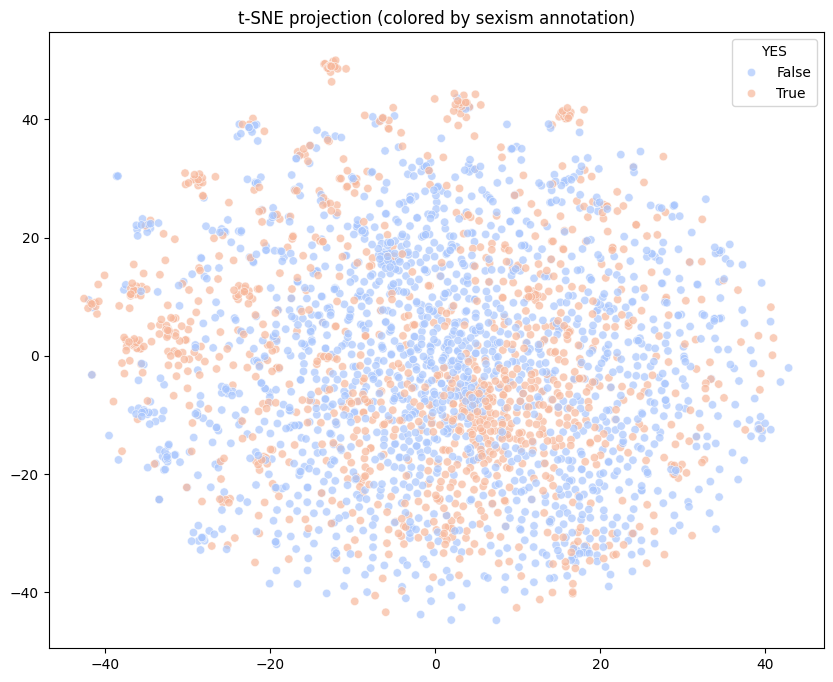

In [58]:
tfidf_en = TfidfVectorizer(max_features=500)
X_en = tfidf_en.fit_transform(data_en['tweet'])

tsne_en = TSNE(n_components=2, random_state=0)
X_embedded_en = tsne_en.fit_transform(X_en.toarray())

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_embedded_en[:, 0], y=X_embedded_en[:, 1],
    hue=data_en['YES'],
    palette='coolwarm',
    alpha=0.7
)
plt.title('t-SNE projection (colored by sexism annotation)')
plt.show()

### UMAP

/opt/miniconda3/envs/nlp/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ll', 've'] not in stop_words.
  warnings.warn(
/opt/miniconda3/envs/nlp/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/miniconda3/envs/nlp/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


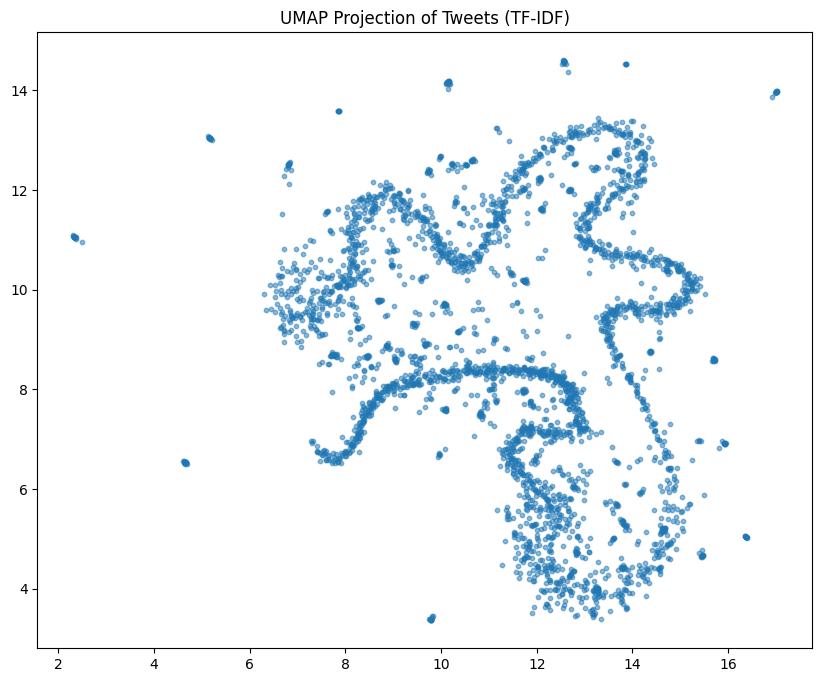

In [59]:
tfidf_en = TfidfVectorizer(max_features=1000, stop_words=list(en_stop_custom))
X_tfidf_en = tfidf_en.fit_transform(data_en['tweet'])

# Apply UMAP
reducer_en = umap.UMAP(random_state=42)
X_umap_en = reducer_en.fit_transform(X_tfidf_en)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(X_umap_en[:, 0], X_umap_en[:, 1], alpha=0.5, s=10)
plt.title("UMAP Projection of Tweets (TF-IDF)")
plt.show()